In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.utils import shuffle
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler, LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, RegressorMixin
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping, Dataset, plot_importance, log_evaluation
import shap
from itertools import product
from scipy.stats import zscore, uniform, randint
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")
ain_voisins = pd.read_csv("../data/data_train_test/ain_tous_voisins.csv")
yvelines_voisins = pd.read_csv("../data/data_train_test/yvelines_tous_voisins.csv")
Naturels = pd.read_csv('../data/firefrance/NATURELSfire.csv')

In [3]:
import numpy as np
class OrdClass(BaseEstimator):
  """
  Helper class that solves ordinal classification (classes that have an order to them eg cold,warm,hot)
  """
  def __init__(self,classifier=None,clf_args=None):
    """
    y needs to be a number that start from 0 and increments by 1
    classifier object needs to be able to return a probability
    """
    self.classifier = classifier
    self.clfs = []
    self.clf_args = clf_args
    self.final_prob = None

  def fit(self,X,y,**fit):
    self.X = X
    self.y = y
    import copy
    no_of_classifiers = np.max(self.y) #since y starts from 0
    self.classes_ = list(range(no_of_classifiers+1))
    if isinstance(self.clf_args,list):
      #for pipelines
      c = self.classifier(self.clf_args)
    elif isinstance(self.clf_args,dict):
      #for normal estimators
       c = self.classifier(**self.clf_args)
    for i in range(no_of_classifiers):
      # make a copy of y because we want to change the values of y
      copy_y = np.copy(self.y)
      # make a binary classification here
      copy_y[copy_y<=i] = 0
      copy_y[copy_y>i] = 1
      classifier = copy.deepcopy(c)
      classifier.fit(self.X,copy_y,**fit)
      self.clfs.append(classifier)
    return self
  def predict_proba(self,test):
    prob_list = []
    final_prob = []
    length = len(self.clfs)
    for clf in self.clfs:
      prob_list.append(clf.predict_proba(test)[:,1])
    for i in range(length+1):
      if i == 0:
        final_prob.append(1-prob_list[i])
      elif i == length:
        final_prob.append(prob_list[i-1])
      else:
        final_prob.append(prob_list[i-1]-prob_list[i])
    answer = np.array(final_prob).transpose()
    self.final_prob= answer
    return answer
  def predict(self,test):
    self.predict_proba(test)
    return np.argmax(self.final_prob,axis=1)
  def score(self,X,y,sample_weight=None):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)

In [4]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')
    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['duree_minutes'] = pd.to_timedelta(ain_data['duree']).dt.total_seconds() / 60

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['duree_minutes'] = pd.to_timedelta(yvelines_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [5]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [6]:
all_data = pd.concat([doubs_data, ain_data, yvelines_data], ignore_index=True)

In [7]:
all_data = all_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(all_data)
all_data.dropna(axis=1, thresh=threshold, inplace=True)

all_data.dropna(inplace=True)

In [8]:
cols_to_drop = [
    'raison_sortie', 'label', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'scale0', 'distance', 'saison'
]

all_data = all_data.drop(columns=[col for col in cols_to_drop if col in all_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

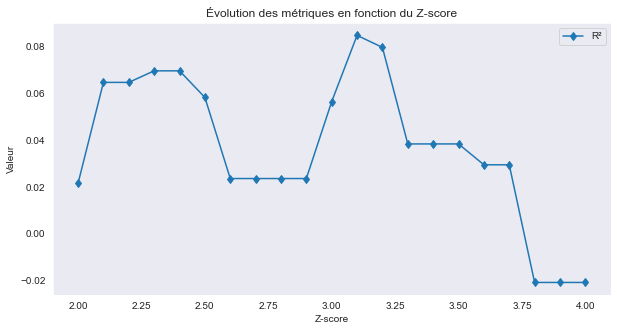

In [9]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

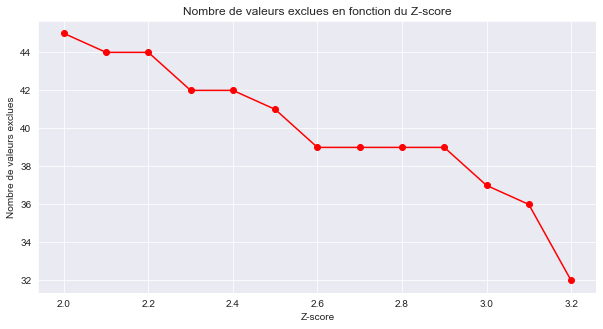

In [10]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  39.349242  58.707707  0.021522   
1   2.1  -447.980329   626.607743  39.085693  57.820369  0.064691   
2   2.2  -473.565759   652.193173  39.085693  57.820369  0.064691   
3   2.3  -499.151189   677.778604  37.802695  57.667296  0.069636   
4   2.4  -524.736620   703.364034  37.802695  57.667296  0.069636   
5   2.5  -550.322050   728.949464  38.641727  58.018904  0.058256   
6   2.6  -575.907480   754.534894  40.401395  59.078463  0.023546   
7   2.7  -601.492911   780.120325  40.401395  59.078463  0.023546   
8   2.8  -627.078341   805.705755  40.401395  59.078463  0.023546   
9   2.9  -652.663771   831.291185  40.401395  59.078463  0.023546   
10  3.0  -678.249201   856.876616  38.979651  58.074081  0.056464   
11  3.1  -703.834632   882.462046  39.778932  58.211628  0.084819   
12  3.2  -729.420062   908.047476  40.393201  64.665954  0.079663   
13  3.3  -755.005492   933.632906 

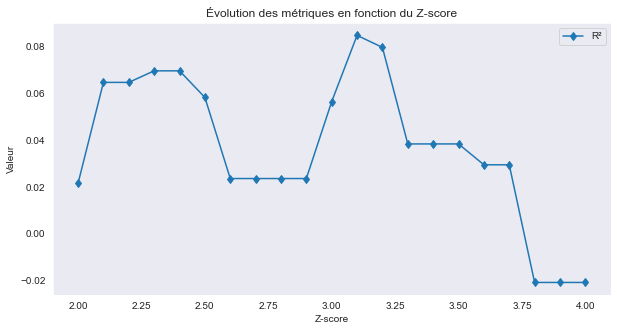

In [11]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

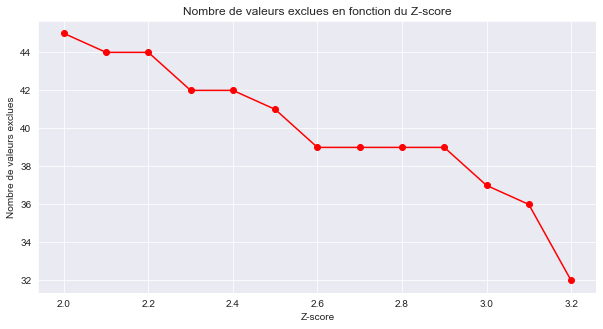

In [12]:
df = all_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

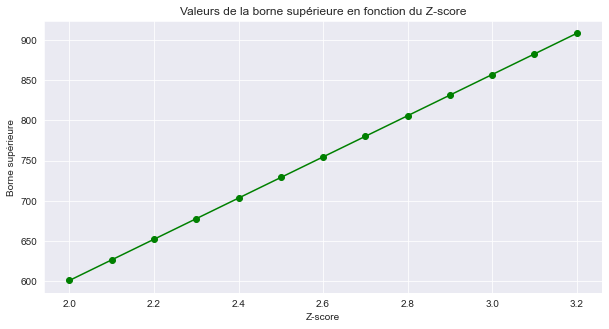

In [13]:
df = all_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [14]:
all_data['z_score'] = np.abs(zscore(all_data['duree_minutes']))

all_data_filtered = all_data[all_data['z_score'] <= 3.1].drop(columns=['z_score'])

values_removed = len(all_data) - len(all_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(all_data) * 100:.2f}%")

Nombre de valeurs supprimées : 36
Pourcentage des données supprimées : 0.47%


In [15]:
all_data_filtered['z_score'] = zscore(all_data_filtered['duree_minutes'])

threshold = 2.9

excluded_values = all_data_filtered[(all_data_filtered['z_score'] > threshold) | (all_data_filtered['z_score'] < -threshold)]

num_excluded = excluded_values.shape[0]

lower_limit = -threshold
upper_limit = threshold

print(f"Nombre de valeurs exclues : {num_excluded}")
print(f"Seuils de z-score : {lower_limit} et {upper_limit}")

Nombre de valeurs exclues : 162
Seuils de z-score : -2.9 et 2.9


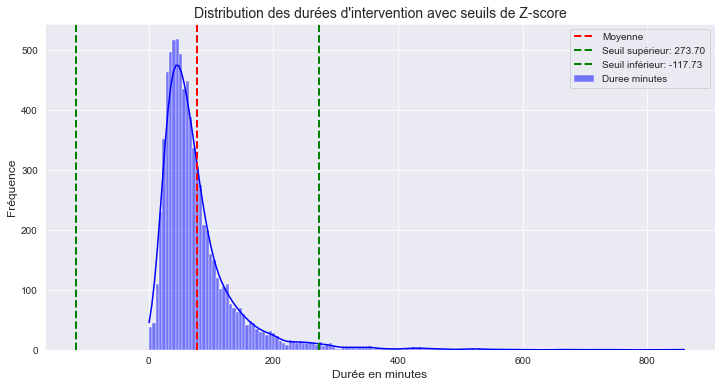

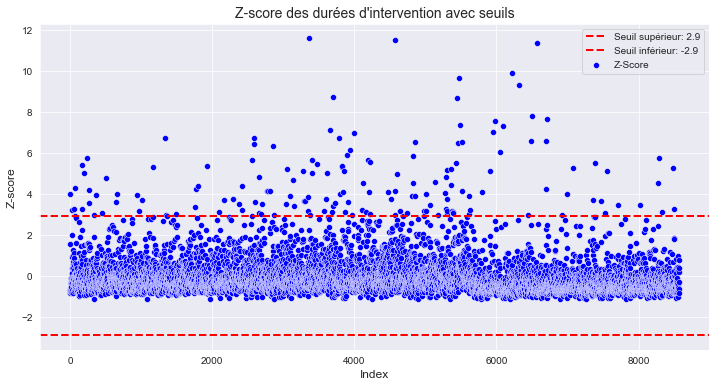

Valeur limite pour le seuil supérieur (z-score = 2.9): 273.70
Valeur limite pour le seuil inférieur (z-score = -2.9): -117.73


In [16]:
mean_duree = all_data_filtered['duree_minutes'].mean()
std_duree = all_data_filtered['duree_minutes'].std()

upper_limit_value = mean_duree + threshold * std_duree
lower_limit_value = mean_duree - threshold * std_duree

plt.figure(figsize=(12, 6))

sns.histplot(all_data_filtered['duree_minutes'], kde=True, color='blue', label='Duree minutes')
plt.axvline(mean_duree, color='red', linestyle='dashed', linewidth=2, label='Moyenne')
plt.axvline(upper_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {upper_limit_value:.2f}')
plt.axvline(lower_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {lower_limit_value:.2f}')

plt.title('Distribution des durées d\'intervention avec seuils de Z-score', fontsize=14)
plt.xlabel('Durée en minutes', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=all_data_filtered.index, y=all_data_filtered['z_score'], color='blue', label='Z-Score')

plt.axhline(y=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {threshold}')
plt.axhline(y=-threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {-threshold}')

plt.title('Z-score des durées d\'intervention avec seuils', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Z-score', fontsize=12)
plt.legend()

plt.show()

print(f"Valeur limite pour le seuil supérieur (z-score = {threshold}): {upper_limit_value:.2f}")
print(f"Valeur limite pour le seuil inférieur (z-score = {-threshold}): {lower_limit_value:.2f}")

In [17]:
all_data_final = all_data_filtered[(all_data_filtered['z_score'] <= threshold) & (all_data_filtered['z_score'] >= -threshold)]

In [18]:
duplicates = all_data_final.duplicated()

nb_duplicates = duplicates.sum()

print(f"Nombre de lignes dupliquées : {nb_duplicates}")

if nb_duplicates > 0:
    display(all_data_final[duplicates])

Nombre de lignes dupliquées : 0


In [19]:
all_data_final["pop_x_route"] = all_data_final["population"] * (all_data_final["motorway"] + all_data_final["primary"] + all_data_final["secondary"] + all_data_final["tertiary"])

all_data_final["NDVI_NDMI"] = all_data_final["NDVI"] * all_data_final["NDMI"]
all_data_final["NDWI_NDSI"] = all_data_final["NDWI"] * all_data_final["NDSI"]

all_data_final["elev_x_foret"] = all_data_final["elevation"] * all_data_final["foret_encoder"]

all_data_final["log_population"] = np.log1p(all_data_final["population"])
all_data_final["sqrt_elevation"] = np.sqrt(all_data_final["elevation"])


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [20]:
print(all_data_final.isna().sum())

hex_id            0
year              0
date              0
departement       0
duree_minutes     0
                 ..
NDVI_NDMI         0
NDWI_NDSI         0
elev_x_foret      0
log_population    0
sqrt_elevation    0
Length: 62, dtype: int64


In [21]:
all_data_final.head()

,hex_id,year,date,departement,duree_minutes,geometry,centroid,centroid_lon,centroid_lat,hour,...,built,bare,snow,z_score,pop_x_route,NDVI_NDMI,NDWI_NDSI,elev_x_foret,log_population,sqrt_elevation
1,871f82d61ffffff,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",POINT (5.80760 47.26166),5.807597,47.261659,19,...,6.345595,0.0,0.0,-0.836524,2.110985,0.036898,0.350821,0.000000,0.693147,10.010617
2,871f82d61ffffff,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",POINT (5.80760 47.26166),5.807597,47.261659,19,...,6.345595,0.0,0.0,-0.648577,2.110985,0.036898,0.350821,0.000000,0.693147,10.010617
3,871f82d4dffffff,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",POINT (5.89468 47.21782),5.894684,47.217820,20,...,10.204597,0.0,0.0,-0.683647,1958.069441,0.101529,0.381016,450.466232,6.300785,9.491746
4,871f82700ffffff,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",POINT (6.31905 46.75590),6.319047,46.755896,12,...,11.164254,0.0,0.0,-0.762432,474.865276,0.173939,0.380367,0.000000,4.882803,26.297684
5,871f82843ffffff,2014.0,2014-11-02,departement-25-doubs,182.050000,"POLYGON ((6.33190 47.38928, 6.33379 47.37729, ...",POINT (6.34859 47.38524),6.348594,47.385244,18,...,2.953746,0.0,0.0,1.542080,1.194126,0.109603,0.401785,0.000000,0.693172,15.858188


In [22]:
all_data_final.columns

Index(['hex_id', 'year', 'date', 'departement', 'duree_minutes', 'geometry',
       'centroid', 'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'z_score', 'pop_x_route', 'NDVI_NDMI',
       'NDWI_NDSI', 'elev_x_foret', 'log_population', 'sqrt_elevation'],
      dtype='object')

In [23]:
cols_to_exclude = [
    'hex_id', 'geometry', 'centroid', 'hour', 'date', 'z_score',
    'departement', 'duree_minutes'
]

cols_to_avg = [col for col in all_data_final.columns if col not in cols_to_exclude]

data_sum = (
    all_data_final
    .groupby(['departement', 'date'], as_index=False)
    .agg({**{col: 'mean' for col in cols_to_avg}, 'duree_minutes': 'sum'})
    .rename(columns={'duree_minutes': 'duree_jour'})
)

In [24]:
data_sum.head()

,departement,date,year,centroid_lon,centroid_lat,month,weekday,NDVI,NDMI,NDBI,...,built,bare,snow,pop_x_route,NDVI_NDMI,NDWI_NDSI,elev_x_foret,log_population,sqrt_elevation,duree_jour
0,departement-01-ain,2018-01-05,2018.0,5.408536,46.120453,1.0,4.0,0.654745,0.094622,-0.094622,...,1.590331,0.0,0.0,66.564859,0.061953,0.367269,0.000000,3.891820,21.987212,64.033333
1,departement-01-ain,2018-01-06,2018.0,5.341068,46.148603,1.0,5.0,0.685372,0.081372,-0.081372,...,4.649089,0.0,0.0,317.462456,0.055770,0.420693,0.000000,5.231108,16.733201,100.300000
2,departement-01-ain,2018-01-12,2018.0,5.701584,45.861396,1.0,4.0,0.672147,0.138282,-0.138282,...,9.146264,0.0,0.0,182.215245,0.092946,0.363786,0.000000,3.761202,16.561047,53.166667
3,departement-01-ain,2018-01-15,2018.0,5.058641,45.869068,1.0,0.0,0.473664,0.004131,-0.004131,...,0.702696,0.0,0.0,310.566264,0.001956,0.268202,0.000000,5.332720,16.583124,63.266667
4,departement-01-ain,2018-01-19,2018.0,5.782200,45.946300,1.0,4.0,0.752247,0.177596,-0.177596,...,0.000000,0.0,0.0,49.132280,0.133596,0.418442,5825.135193,2.708053,28.847221,84.583333


In [25]:
data_sum = data_sum[data_sum['departement'] == 'departement-01-ain']

In [26]:
Naturels = Naturels[['date', 'FL_CCR_CCF', 'nb_eng_CC', 'IN', 'coef']]

Naturels['date'] = pd.to_datetime(Naturels['date'])
data_sum['date'] = pd.to_datetime(data_sum['date'])

data_sum = data_sum.merge(Naturels, on='date', how='left')

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning


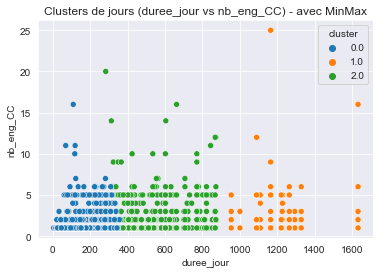

In [27]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sélection des variables
X = data_sum[['duree_jour', 'nb_eng_CC']].dropna()

# 2. Normalisation Min-Max
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# 4. Ajout au DataFrame
data_sum.loc[X.index, 'cluster'] = clusters

# 5. Visualisation
sns.scatterplot(data=data_sum, x='duree_jour', y='nb_eng_CC', hue='cluster', palette='tab10')
plt.title("Clusters de jours (duree_jour vs nb_eng_CC) - avec MinMax")
plt.show()